# Estratégias de Agendamento de Purificação

Em redes quânticas, a comunicação e as operações dependem da distribuição de pares EPR. O problema central é que os canais físicos por onde esses pares transitam são ruidosos. Esse ruído degrada a fidelidade do emaranhamento ao longo do tempo e da distância.

Para resolver a degradação, utiliza-se a purificação: sacrificar vários pares de baixa fidelidade para destilar um único par de alta fidelidade. No entanto, a purificação é um processo probabilístico e esbarra em um grande gargalo nas abordagens tradicionais:

Se o sistema subestimar o ruído do canal, ele não aloca pares suficientes, a purificação falha no meio do processo e todo o progresso (e os pares já gastos) é perdido. Se o sistema superestimar o ruído, ele aloca pares demais, alcança a fidelidade cedo e descarta/desperdiça os pares que sobraram. Além disso, a falta de conhecimento prévio exato sobre o comportamento do canal torna impossível prever perfeitamente quantos ciclos de purificação serão necessários desde o início.

Este notebook tem como objetivo demonstrar, validar e analisar o funcionamento do módulo de purificação implementado na camada de enlace (LinkLayer) do simulador QuantumNet.

### Sumário
1. Motor Probabilístico de Erro de Canal
2. Helper: Logger de Purificação
3. Cenário 1: O Caso Ideal (Prova de Sanidade da Matemática)
4. Cenário 2: O Fracasso da Abordagem Estática (O Problema)
5. Cenário 3: O Agendador Híbrido Salvando a Rede (A Solução)



In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import random
import numpy as np
import matplotlib.pyplot as plt

from quantumnet.runtime import Clock
from quantumnet.topology.network import Network
from quantumnet.utils import MetricsCollector

## Motor Probabilístico de Erro de Canal

Antes dos cenários, visualizamos as curvas do motor probabilístico.
Isso mostra como o tipo de ruído afeta tanto a $P_{sucesso}$ quanto a $F_{nova}$.

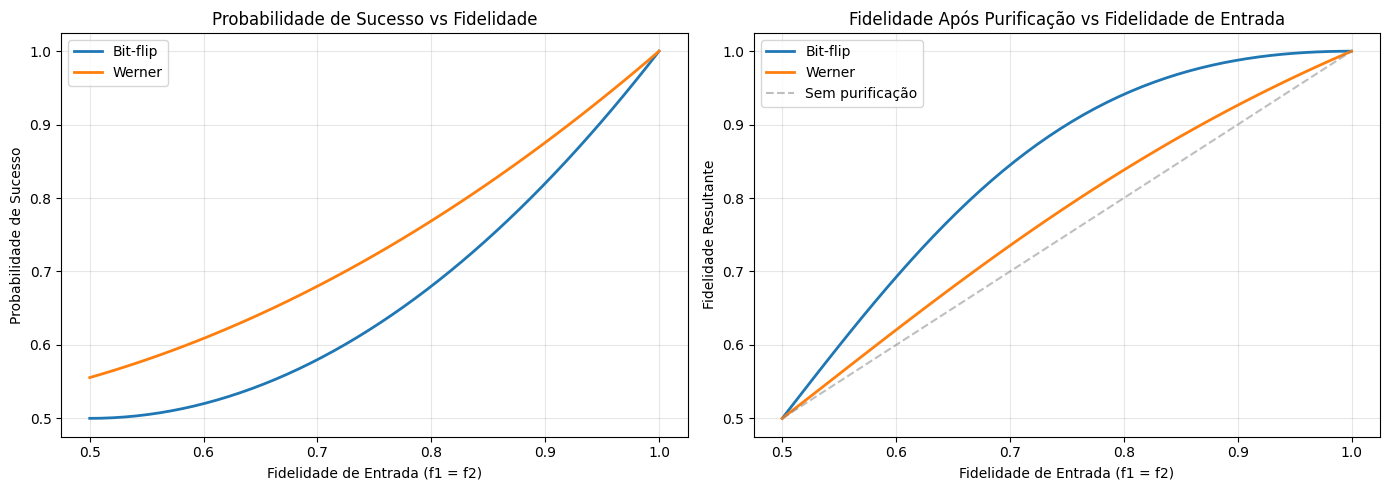

In [2]:
clock = Clock()
net = Network(clock=clock)
net.set_ready_topology('Line', 2)
ll = net.linklayer

fidelities = np.linspace(0.5, 1.0, 50)

bf_p, bf_f = [], []
w_p, w_f = [], []

for fid in fidelities:
    p, f = ll.channel_error_engine(fid, fid, 'bit-flip')
    bf_p.append(p)
    bf_f.append(f)
    
    p, f = ll.channel_error_engine(fid, fid, 'werner')
    w_p.append(p)
    w_f.append(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fidelities, bf_p, label='Bit-flip', linewidth=2)
axes[0].plot(fidelities, w_p, label='Werner', linewidth=2)
axes[0].set_xlabel('Fidelidade de Entrada (f1 = f2)')
axes[0].set_ylabel('Probabilidade de Sucesso')
axes[0].set_title('Probabilidade de Sucesso vs Fidelidade')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(fidelities, bf_f, label='Bit-flip', linewidth=2)
axes[1].plot(fidelities, w_f, label='Werner', linewidth=2)
axes[1].plot(fidelities, fidelities, '--', color='gray', alpha=0.5, label='Sem purificação')
axes[1].set_xlabel('Fidelidade de Entrada (f1 = f2)')
axes[1].set_ylabel('Fidelidade Resultante')
axes[1].set_title('Fidelidade Após Purificação vs Fidelidade de Entrada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/purification_engine.png', dpi=150, bbox_inches='tight')
plt.show()

## Helper: Logger de Purificação

Registra listeners no clock para imprimir logs narrativos de cada evento de purificação.

In [3]:
def attach_purification_logger(clock):
    """Registra listeners que imprimem logs detalhados de purificação."""
    
    def on_provisioned(clk, alice, bob, strategy, rounds, estimated_pairs, pool_size, **_):
        print(f'[t={clk.now}] PROVISIONED: Canal ({alice},{bob})')
        print(f'         Estratégia: {strategy} | Rounds planejados: {rounds}')
        print(f'         Pares estimados: {estimated_pairs} | Pool de reserva: {pool_size}')
        print()
    
    def on_started(clk, alice, bob, strategy, rounds, initial_pairs, pool_size, **_):
        print(f'[t={clk.now}] STARTED: Purificação {strategy} iniciada no canal ({alice},{bob})')
        print(f'         Pares alocados: {initial_pairs} | Pool disponível: {pool_size}')
        print(f'         {"=" * 50}')
    
    def on_round_success(clk, alice, bob, round, fidelity, **_):
        bar = int(fidelity * 30) * '#'
        print(f'         Round {round}: SUCESSO  F = {fidelity:.6f}  [{bar}]')
    
    def on_round_failed(clk, alice, bob, round, **_):
        print(f'         Round {round}: FALHA    Teste probabilístico falhou. Pares destruídos.')
    
    def on_pool_recovery(clk, alice, bob, round, fidelity, pool_remaining, **_):
        print(f'         >>> RECUPERAÇÃO DO POOL: Falha detectada no round {round}!')
        print(f'             Aborto evitado pelo Agendador Híbrido.')
        print(f'             Pares estragados descartados. 2 pares injetados do Pool de Reserva.')
        print(f'             Nova tentativa: F = {fidelity:.6f} | Pool restante: {pool_remaining}')
    
    def on_success(clk, alice, bob, strategy, fidelity, surviving_pairs, **_):
        print(f'         {"=" * 50}')
        print(f'[t={clk.now}] SUCCESS: Purificação concluída no canal ({alice},{bob})')
        print(f'         Fidelidade final: {fidelity:.6f} | Pares sobreviventes: {surviving_pairs}')
        print()
    
    def on_failed(clk, alice, bob, strategy, reason, **kw):
        print(f'         {"=" * 50}')
        print(f'[t={clk.now}] FAILED: Purificação ABORTADA no canal ({alice},{bob})')
        print(f'         Motivo: {reason}')
        if 'round' in kw:
            print(f'         Falhou no round: {kw["round"]}')
        print(f'         Todos os pares EPR envolvidos foram DESTRUÍDOS e desperdiçados.')
        print()
    
    clock.on('purification_provisioned', on_provisioned)
    clock.on('purification_started', on_started)
    clock.on('purification_round_success', on_round_success)
    clock.on('purification_round_failed', on_round_failed)
    clock.on('purification_pool_recovery', on_pool_recovery)
    clock.on('purification_success', on_success)
    clock.on('purification_failed', on_failed)

print('Logger de purificação carregado.')

Logger de purificação carregado.


## Cenário 1: O Caso Ideal <br> (Prova de Sanidade da Matemática)

Aqui o canal tem somente o ruído simples (`bit-flip`) e EPRs com fidelidade inicial alta (1.0).
Utiliza-se a Estratégia Simétrica com 2 rounds, **sem pool de backup** (pool_size=0).

**Expectativa:** A probabilidade de sucesso no bit-flip é alta (~0.78 para f=0.9). Todos os rounds devem passar, e a fidelidade sobe a cada round.

In [4]:
random.seed(42)

clock1 = Clock()
net1 = Network(clock=clock1)
net1.config.defaults.channel_noise_type = 'bit-flip'
net1.config.defaults.eprs_per_channel = 10
net1.config.decoherence.per_timeslot = 0.95
net1.set_ready_topology('Line', 2)

attach_purification_logger(clock1)

# Mostrar estado inicial do canal
eprs = net1.graph.edges[0, 1]['eprs']
noise = net1.graph.edges[0, 1]['noise_type']
f_inicial = eprs[0].current_fidelity  # Capturar antes do clock.run() expirar os EPRs via TTL
print(f'Canal (0,1): {len(eprs)} EPRs disponíveis | Ruído: {noise}')
print(f'Fidelidade inicial dos EPRs: {f_inicial:.4f}')
print()

# Mostrar cálculo do motor antes de executar
p_succ, f_new = net1.linklayer.channel_error_engine(f_inicial, f_inicial, noise)
print(f'Motor Probabilístico (bit-flip): f1=f2={f_inicial:.4f}')
print(f'  P_sucesso = {p_succ:.4f} (alta — canal pouco ruidoso)')
print(f'  F_nova    = {f_new:.4f} (ganho de fidelidade)\n')

# Executar purificação
result1 = {}
def on_done1(success, epr=None):
    result1['success'] = success
    result1['fidelity'] = epr.current_fidelity if epr else None

net1.linklayer.run_purification(
    0, 1, strategy='symmetric', num_rounds=2,
    pool_size=0, on_complete=on_done1)

clock1.run()

# Veredicto
print('--- VEREDICTO ---')
print(f'A purificação bit-flip convergiu sem falhas.')
print(f'Fidelidade: {f_inicial:.4f} -> {result1["fidelity"]:.6f}')
print(f'A matemática do motor probabilístico está validada.')

Canal (0,1): 10 EPRs disponíveis | Ruído: bit-flip
Fidelidade inicial dos EPRs: 1.0000

Motor Probabilístico (bit-flip): f1=f2=1.0000
  P_sucesso = 1.0000 (alta — canal pouco ruidoso)
  F_nova    = 1.0000 (ganho de fidelidade)

[t=0] PROVISIONED: Canal (0,1)
         Estratégia: symmetric | Rounds planejados: 2
         Pares estimados: 4 | Pool de reserva: 0

[t=1] STARTED: Purificação symmetric iniciada no canal (0,1)
         Pares alocados: 4 | Pool disponível: 0
         Round 1: SUCESSO  F = 0.997238  [#############################]
         Round 1: SUCESSO  F = 0.997238  [#############################]
         Round 2: SUCESSO  F = 0.996924  [#############################]
[t=1] SUCCESS: Purificação concluída no canal (0,1)
         Fidelidade final: 0.996924 | Pares sobreviventes: 1

--- VEREDICTO ---
A purificação bit-flip convergiu sem falhas.
Fidelidade: 1.0000 -> 0.996924
A matemática do motor probabilístico está validada.


## Cenário 2: O Fracasso da Abordagem Estática <br> (O Problema)

Nesse cenário o canal tem ruídos com modelo de ``'Werner'``. A Purificação Simétrica acontece com 2 rounds, **sem pool de backup** (pool_size=0).

**Expectativa:** O ruído de Werner derruba a probabilidade de sucesso. Em algum round, o teste probabilístico vai falhar. Sem reservas, o processo inteiro aborta e todos os pares são desperdiçados. Isso evidencia a limitação clássica das redes quânticas ruidosas.

In [5]:
random.seed(5)

clock2 = Clock()
net2 = Network(clock=clock2)
net2.config.defaults.channel_noise_type = 'werner'
net2.config.defaults.eprs_per_channel = 10
net2.config.decoherence.per_timeslot = 0.90
net2.set_ready_topology('Line', 2)

attach_purification_logger(clock2)

# Estado inicial
eprs2 = net2.graph.edges[0, 1]['eprs']
noise2 = net2.graph.edges[0, 1]['noise_type']
print(f'Canal (0,1): {len(eprs2)} EPRs disponíveis | Ruído: {noise2}')
print(f'Fidelidade inicial dos EPRs: {eprs2[0].current_fidelity:.4f}')
print()

# Mostrar que Werner tem probabilidade MAIS BAIXA
f = eprs2[0].current_fidelity
p_bf, f_bf = net2.linklayer.channel_error_engine(f, f, 'bit-flip')
p_w, f_w = net2.linklayer.channel_error_engine(f, f, 'werner')
print(f'Comparação para f1=f2={f:.4f}:')
print(f'  Bit-flip: P_sucesso={p_bf:.4f}, F_nova={f_bf:.4f}')
print(f'  Werner:   P_sucesso={p_w:.4f}, F_nova={f_w:.4f}')
print(f'  Werner derruba a probabilidade e a fidelidade resultante.\n')

# Contar EPRs antes
eprs_antes = len(net2.graph.edges[0, 1]['eprs'])

# Executar purificação SEM pool
result2 = {}
def on_done2(success, epr=None):
    result2['success'] = success
    result2['fidelity'] = epr.current_fidelity if epr else None

net2.linklayer.run_purification(
    0, 1, strategy='symmetric', num_rounds=2,
    pool_size=0, on_complete=on_done2)

clock2.run()

# Contar EPRs depois
eprs_depois = len(net2.graph.edges[0, 1]['eprs'])

# Veredicto
print('--- VEREDICTO ---')
print(f'Canal ruidoso (Werner) sem redundância: FALHA.')
print(f'EPRs no canal: {eprs_antes} antes -> {eprs_depois} depois.')
print(f'{eprs_antes - eprs_depois} pares EPR foram consumidos e DESTRUÍDOS sem resultado útil.')
print(f'A abordagem estática NÃO consegue lidar com canais severamente ruidosos.')

Canal (0,1): 10 EPRs disponíveis | Ruído: werner
Fidelidade inicial dos EPRs: 1.0000

Comparação para f1=f2=1.0000:
  Bit-flip: P_sucesso=1.0000, F_nova=1.0000
  Werner:   P_sucesso=1.0000, F_nova=1.0000
  Werner derruba a probabilidade e a fidelidade resultante.

[t=0] PROVISIONED: Canal (0,1)
         Estratégia: symmetric | Rounds planejados: 2
         Pares estimados: 4 | Pool de reserva: 0

[t=1] STARTED: Purificação symmetric iniciada no canal (0,1)
         Pares alocados: 4 | Pool disponível: 0
         Round 1: SUCESSO  F = 0.926396  [###########################]
         Round 1: FALHA    Teste probabilístico falhou. Pares destruídos.
[t=1] FAILED: Purificação ABORTADA no canal (0,1)
         Motivo: all_rounds_failed
         Falhou no round: 2
         Todos os pares EPR envolvidos foram DESTRUÍDOS e desperdiçados.

--- VEREDICTO ---
Canal ruidoso (Werner) sem redundância: FALHA.
EPRs no canal: 10 antes -> 0 depois.
10 pares EPR foram consumidos e DESTRUÍDOS sem resultado 

## Cenário 3: O Agendador Híbrido Salvando a Rede (A Solução)

Porr fim, o exato mesmo canal ruidoso do Cenário 2 (Werner, mesma seed). Nesse contexto, chama-se o Agendador Híbrido com um pool de 6 pares de reserva.

**Expectativa:** A mesma falha probabilística acontece novamente, mas desta vez o Agendador Híbrido intercepta a falha, descarta os pares estragados, injeta pares do pool de reserva e repete a tentativa. O processo completa com sucesso.

In [6]:
# MESMA SEED e MESMA CONFIGURAÇÃO do Cenário 2
random.seed(5)

clock3 = Clock()
net3 = Network(clock=clock3)
net3.config.defaults.channel_noise_type = 'werner'
net3.config.defaults.eprs_per_channel = 10
net3.config.decoherence.per_timeslot = 0.90
net3.set_ready_topology('Line', 2)

attach_purification_logger(clock3)

# Estado inicial — idêntico ao Cenário 2
eprs3 = net3.graph.edges[0, 1]['eprs']
noise3 = net3.graph.edges[0, 1]['noise_type']
print(f'Canal (0,1): {len(eprs3)} EPRs disponíveis | Ruído: {noise3}')
print(f'Fidelidade inicial dos EPRs: {eprs3[0].current_fidelity:.4f}')
print(f'Agora COM pool de reserva de 6 pares.\n')

# Contar EPRs antes
eprs_antes3 = len(net3.graph.edges[0, 1]['eprs'])

# Executar purificação COM pool
result3 = {}
def on_done3(success, epr=None):
    result3['success'] = success
    result3['fidelity'] = epr.current_fidelity if epr else None

net3.linklayer.run_purification(
    0, 1, strategy='symmetric', num_rounds=2,
    pool_size=6, on_complete=on_done3)

clock3.run()

# Contar EPRs depois
eprs_depois3 = len(net3.graph.edges[0, 1]['eprs'])

# Veredicto comparativo
print('--- VEREDICTO ---')
print(f'Mesmo canal ruidoso (Werner), mesma seed, mesmas condições.')
print(f'Cenário 2 (sem pool):  FALHA   — todos os pares destruídos.')
print(f'Cenário 3 (com pool):  SUCESSO — fidelidade final = {result3["fidelity"]:.6f}')
print(f'EPRs no canal após purificação: {eprs_depois3}')
print()
print(f'O Agendador Híbrido interceptou as falhas probabilísticas,')
print(f'injetou pares do pool de reserva e completou a purificação.')
print(f'A rede foi salva.')

Canal (0,1): 10 EPRs disponíveis | Ruído: werner
Fidelidade inicial dos EPRs: 1.0000
Agora COM pool de reserva de 6 pares.

[t=0] PROVISIONED: Canal (0,1)
         Estratégia: symmetric | Rounds planejados: 2
         Pares estimados: 4 | Pool de reserva: 6

[t=1] STARTED: Purificação symmetric iniciada no canal (0,1)
         Pares alocados: 4 | Pool disponível: 6
         Round 1: SUCESSO  F = 0.926396  [###########################]
         >>> RECUPERAÇÃO DO POOL: Falha detectada no round 1!
             Aborto evitado pelo Agendador Híbrido.
             Pares estragados descartados. 2 pares injetados do Pool de Reserva.
             Nova tentativa: F = 0.926396 | Pool restante: 4
         >>> RECUPERAÇÃO DO POOL: Falha detectada no round 2!
             Aborto evitado pelo Agendador Híbrido.
             Pares estragados descartados. 2 pares injetados do Pool de Reserva.
             Nova tentativa: F = 0.926396 | Pool restante: 2
[t=1] SUCCESS: Purificação concluída no canal (0,